<a href="https://colab.research.google.com/github/ChiariniFrancesco/FSL_Segmentation_Bio/blob/main/pannuke_exploration_silvia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import useful libraries
import os #fornisce funzioni per interagire con il sistema operativo
import glob #trova file con pattern specifici, tipo cerca tutti i file .jpg
import numpy as np #per il calcolo numerico
import pandas as pd #per manipolare dati tabulari tipo exel
import matplotlib.pyplot as plt #per creare e grafici e visualizzazioni di dati
import scipy.io as sio # useful because ground truth labels are uploaded as .mat files
import cv2 # per cariche e processare le immagini
import matplotlib.patches as patches #per disegnare forme sopra le immagini
from PIL import Image

In [2]:
%pwd

'/Users/silvia/FSL_Segmentation_Bio'

In [3]:
DATA_PATH = 'data/raw/pannuke'

os.listdir(DATA_PATH)

['validate', '.DS_Store', 'train', 'model.h5']

In [4]:
image_paths = glob.glob(os.path.join(DATA_PATH, "train", "images", "*.png*")) \
             + glob.glob(os.path.join(DATA_PATH, "validate", "images", "*.png*"))
print(len(image_paths))

7901


In [6]:
# array vuoti per ogni canale
R_values = []
G_values = []
B_values = []

# loop su tutte le immagini
for img_path in image_paths:
    img = Image.open(img_path)          # apri immagine
    img = np.array(img)                  # conversione in array numpy
    if img.ndim == 3:                    # RGB
        R_values.extend(img[:,:,0].flatten()[::10])
        G_values.extend(img[:,:,1].flatten()[::10])
        B_values.extend(img[:,:,2].flatten()[::10])

                  R             G             B
count  5.178315e+07  5.178315e+07  5.178315e+07
mean   1.797224e+02  1.461956e+02  1.890458e+02
std    4.556575e+01  5.761882e+01  4.852783e+01
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    1.500000e+02  1.030000e+02  1.610000e+02
50%    1.840000e+02  1.470000e+02  2.000000e+02
75%    2.150000e+02  1.900000e+02  2.280000e+02
max    2.550000e+02  2.550000e+02  2.550000e+02


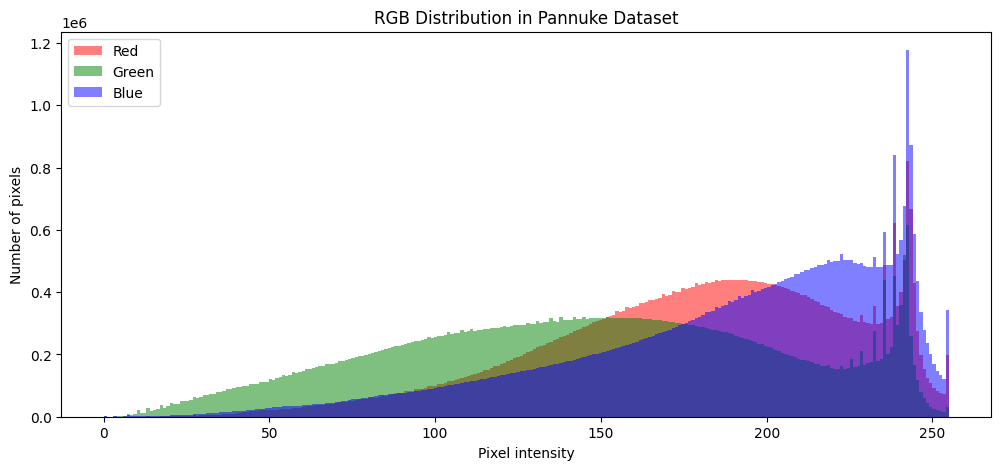

In [7]:
df = pd.DataFrame({
    'R': R_values,
    'G': G_values,
    'B': B_values
})

print(df.describe())

plt.figure(figsize=(12,5))

plt.hist(R_values, bins=256, color='red', alpha=0.5, label='Red')
plt.hist(G_values, bins=256, color='green', alpha=0.5, label='Green')
plt.hist(B_values, bins=256, color='blue', alpha=0.5, label='Blue')

plt.title("RGB Distribution in Pannuke Dataset")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.legend()
plt.show()

                  R             G             B
count  5.178315e+07  5.178315e+07  5.178315e+07
mean   1.797224e+02  1.461956e+02  1.890458e+02
std    4.556575e+01  5.761882e+01  4.852783e+01
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    1.500000e+02  1.030000e+02  1.610000e+02
50%    1.840000e+02  1.470000e+02  2.000000e+02
75%    2.150000e+02  1.900000e+02  2.280000e+02
max    2.550000e+02  2.550000e+02  2.550000e+02


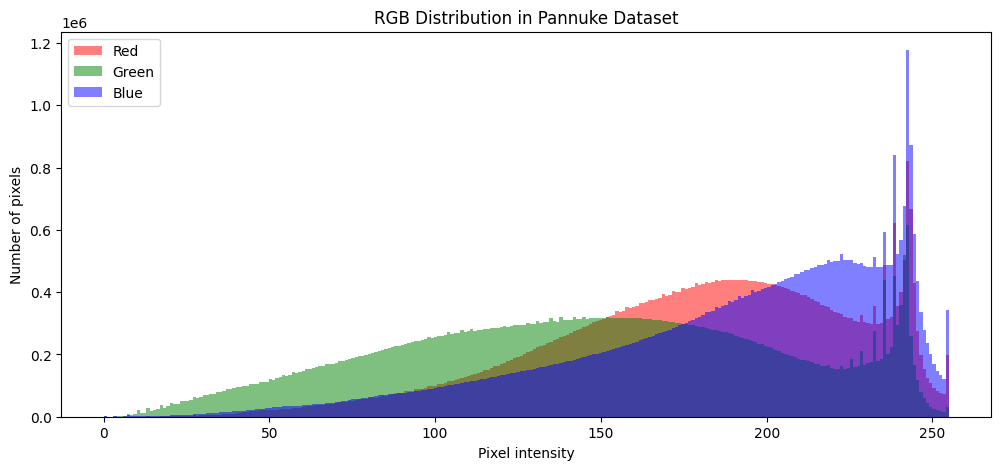

In [8]:
df = pd.DataFrame({
    'R': R_values,
    'G': G_values,
    'B': B_values
})

print(df.describe())

plt.figure(figsize=(12,5))

plt.hist(R_values, bins=256, color='red', alpha=0.5, label='Red')
plt.hist(G_values, bins=256, color='green', alpha=0.5, label='Green')
plt.hist(B_values, bins=256, color='blue', alpha=0.5, label='Blue')

plt.title("RGB Distribution in Pannuke Dataset")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.legend()
plt.show()

In [9]:
# lista di tutte le maschere
mask_paths = glob.glob(os.path.join(DATA_PATH, "train", "masks", "*.png")) \
           + glob.glob(os.path.join(DATA_PATH, "validate", "masks", "*.png"))

nuclei_counts = []

for mask_path in mask_paths:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # carica in scala di grigi
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)  # binarizza
    num_labels, _ = cv2.connectedComponents(binary)
    nuclei_counts.append(num_labels - 1)  # sottrai 1 perché 0 = sfondo

In [10]:
densities = []

for mask_path, count in zip(mask_paths, nuclei_counts):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    area = mask.shape[0] * mask.shape[1]  # numero totale di pixel
    density = count / area
    densities.append(density)

# media e deviazione standard
import numpy as np
print("Densità media:", np.mean(densities))
print("Deviazione standard:", np.std(densities))

Densità media: 0.00031055044394597995
Deviazione standard: 0.0002340104048383712


In [11]:
nuclei_counts = []
densities = []

#loop su ogni maschera
for mask_path in mask_paths:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # carica in scala di grigi
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)  # binarizza

    # conta i nuclei
    num_labels, _ = cv2.connectedComponents(binary)
    nuclei_counts.append(num_labels - 1)  # sottrai 1 per lo sfondo

    # densità nucleare
    area = mask.shape[0] * mask.shape[1]  # numero totale di pixel
    densities.append((num_labels - 1) / area)
# statistiche globali
mean_density = np.mean(densities)
std_density = np.std(densities)

print("Numero di nuclei per immagine (prime 10 immagini):", nuclei_counts[:10])
print("Densità nucleare media:", mean_density)
print("Deviazione standard:", std_density)


Numero di nuclei per immagine (prime 10 immagini): [14, 28, 4, 10, 20, 9, 12, 25, 21, 27]
Densità nucleare media: 0.00031055044394597995
Deviazione standard: 0.0002340104048383712


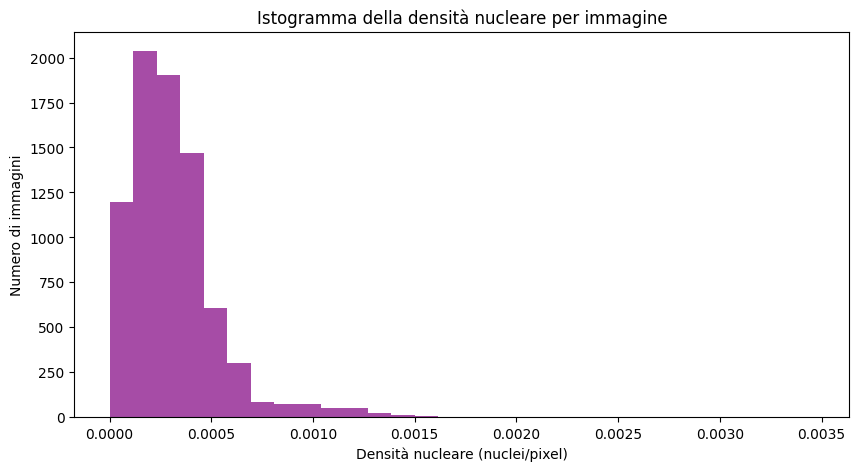

In [12]:
#istogramma densità 

plt.figure(figsize=(10,5))
plt.hist(densities, bins=30, color='purple', alpha=0.7)
plt.title("Istogramma della densità nucleare per immagine")
plt.xlabel("Densità nucleare (nuclei/pixel)")
plt.ylabel("Numero di immagini")
plt.show()

 TRAIN set:
Numero nuclei per immagine (prime 10): [14, 28, 4, 10, 20, 9, 12, 25, 21, 27]
Densità media: 0.0003109307712284563
Deviazione standard: 0.000235527727288374

 VALIDATE set:
Numero nuclei per immagine (prime 10): [24, 13, 10, 29, 8, 24, 28, 18, 27, 16]
Densità media: 0.000308394935060654
Deviazione standard: 0.0002252057683431414


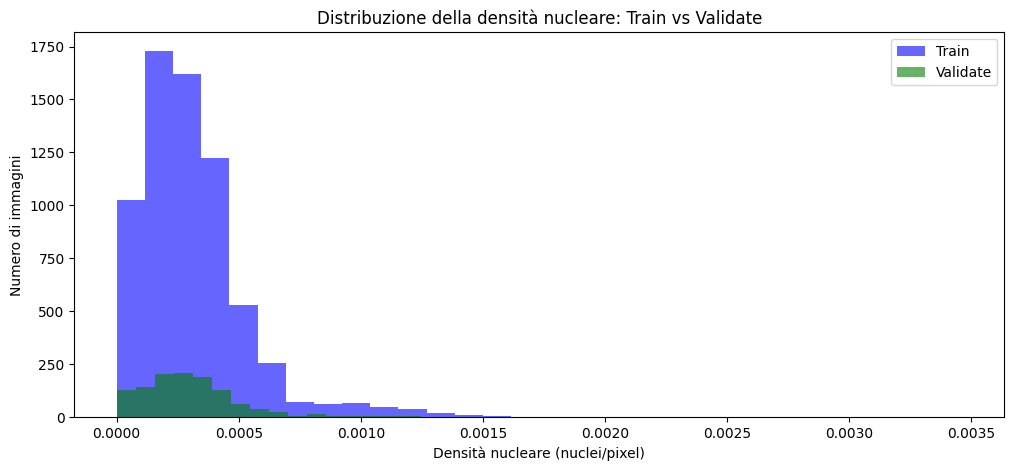

In [14]:
# Analisi separata TRAIN vs VALIDATE

train_masks = os.path.join(DATA_PATH, "train", "masks")
validate_masks = os.path.join(DATA_PATH, "validate", "masks")

def analyze_masks(mask_folder):
    mask_paths = glob.glob(os.path.join(mask_folder, "*.png"))
    nuclei_counts = []
    densities = []
    for mask_path in mask_paths:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        num_labels, _ = cv2.connectedComponents(binary)
        nuclei_counts.append(num_labels - 1)
        area = mask.shape[0] * mask.shape[1]
        densities.append((num_labels - 1) / area)
    return nuclei_counts, densities

train_counts, train_densities = analyze_masks(train_masks)
validate_counts, validate_densities = analyze_masks(validate_masks)

print(" TRAIN set:")
print("Numero nuclei per immagine (prime 10):", train_counts[:10])
print("Densità media:", np.mean(train_densities))
print("Deviazione standard:", np.std(train_densities))

print("\n VALIDATE set:")
print("Numero nuclei per immagine (prime 10):", validate_counts[:10])
print("Densità media:", np.mean(validate_densities))
print("Deviazione standard:", np.std(validate_densities))

# Istogramma comparativo
plt.figure(figsize=(12,5))
plt.hist(train_densities, bins=30, alpha=0.6, label='Train', color='blue')
plt.hist(validate_densities, bins=30, alpha=0.6, label='Validate', color='green')
plt.title("Distribuzione della densità nucleare: Train vs Validate")
plt.xlabel("Densità nucleare (nuclei/pixel)")
plt.ylabel("Numero di immagini")
plt.legend()
plt.show()